Loaded example-star files from: /mnt/zfs/jupyter-p03/home/b6carter/Standard MS System repaired

Building sequence: Standard
Solving model for Tc = 4.000e+07 K
  found: M=119.591 Msun, R=7.798 Rsun, L=1.613e+07 Lsun, Teff=130984 K, rho_c=4.874e+02
Solving model for Tc = 3.240e+07 K
  found: M=25.373 Msun, R=4.609 Rsun, L=8.325e+04 Lsun, Teff=45667 K, rho_c=1.677e+03
Solving model for Tc = 3.000e+07 K
  found: M=13.130 Msun, R=3.028 Rsun, L=1.791e+04 Lsun, Teff=38374 K, rho_c=3.720e+03
Solving model for Tc = 2.624e+07 K
  found: M=5.868 Msun, R=2.234 Rsun, L=1.616e+03 Lsun, Teff=24484 K, rho_c=1.213e+04
Solving model for Tc = 2.350e+07 K
  found: M=3.164 Msun, R=1.122 Rsun, L=2.480e+02 Lsun, Teff=21624 K, rho_c=3.040e+04
Solving model for Tc = 2.125e+07 K
  found: M=2.003 Msun, R=0.760 Rsun, L=4.934e+01 Lsun, Teff=17549 K, rho_c=6.348e+04
Solving model for Tc = 2.000e+07 K
  found: M=1.695 Msun, R=0.787 Rsun, L=2.082e+01 Lsun, Teff=13899 K, rho_c=8.834e+04
Solving model for Tc = 1.900e+0

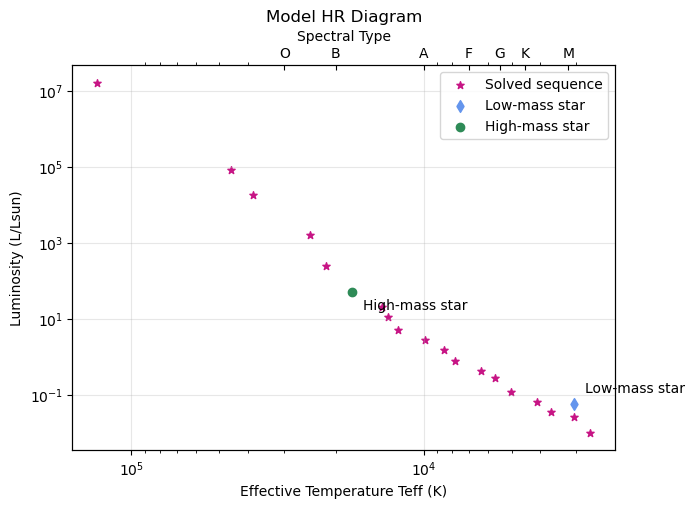

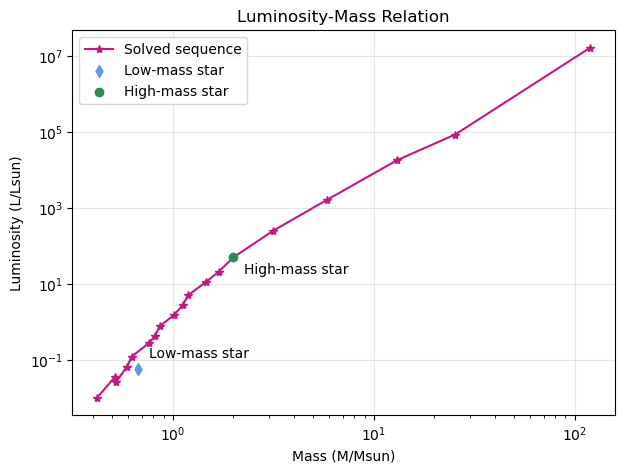

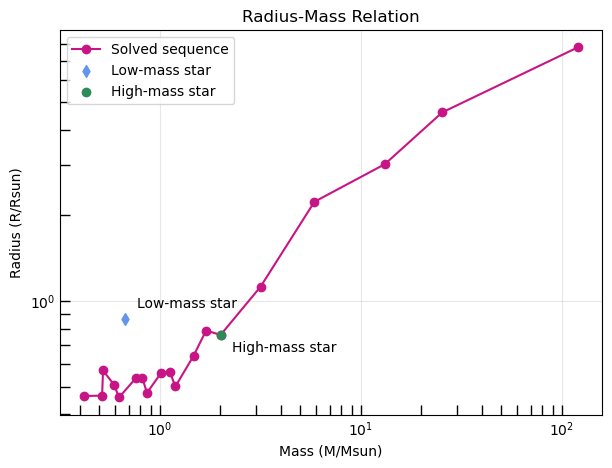


Low-mass star (provided reference file):
  M = 0.673 Msun
  R = 0.865 Rsun
  L = 5.877e-02 Lsun
  Teff = 3056 K


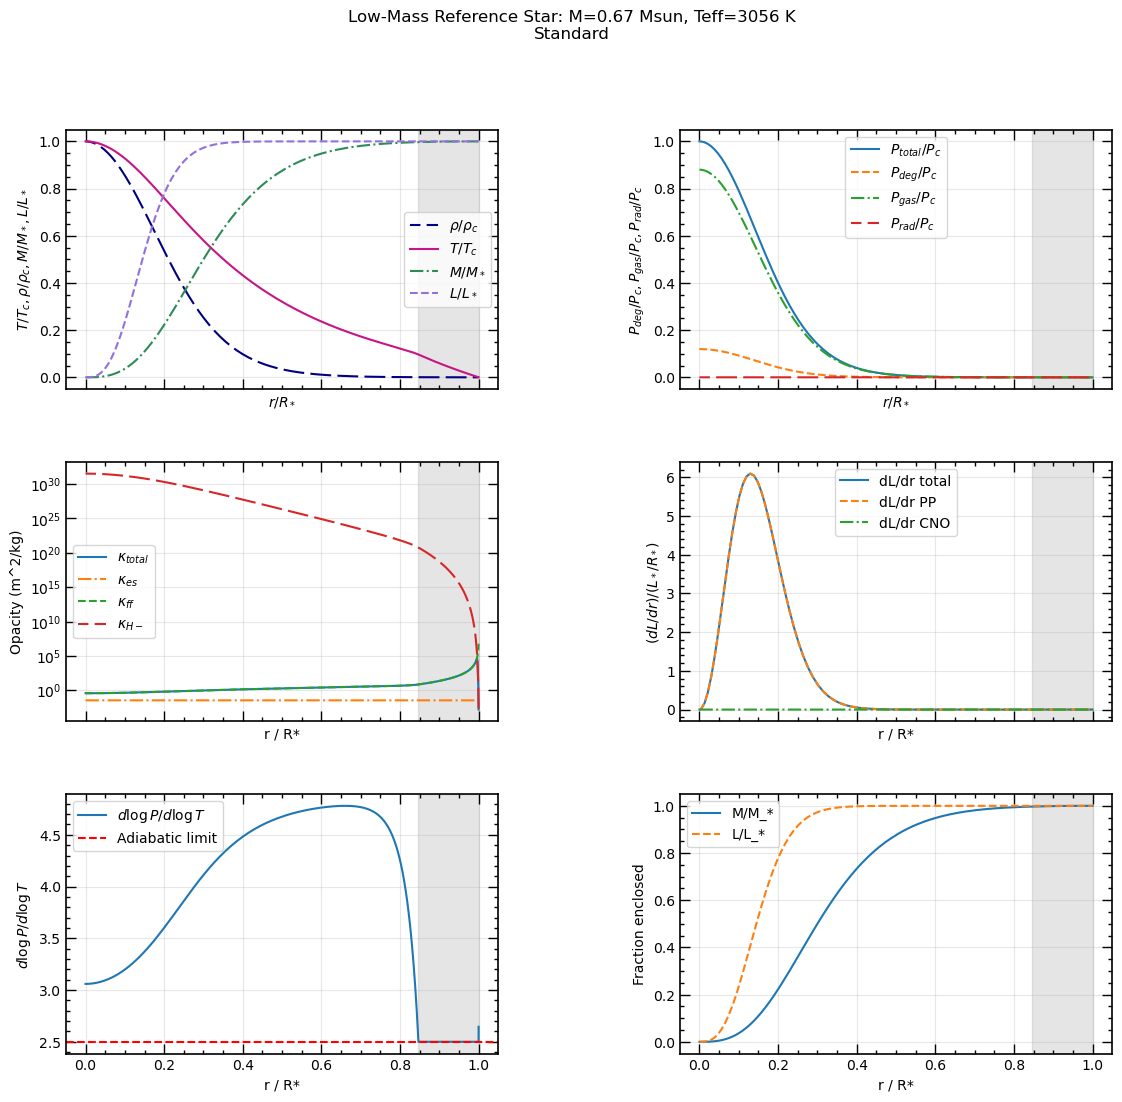


High-mass star (generated sequence model above 2 Msun):
  M = 2.003 Msun
  R = 0.760 Rsun
  L = 4.934e+01 Lsun
  Teff = 17549 K


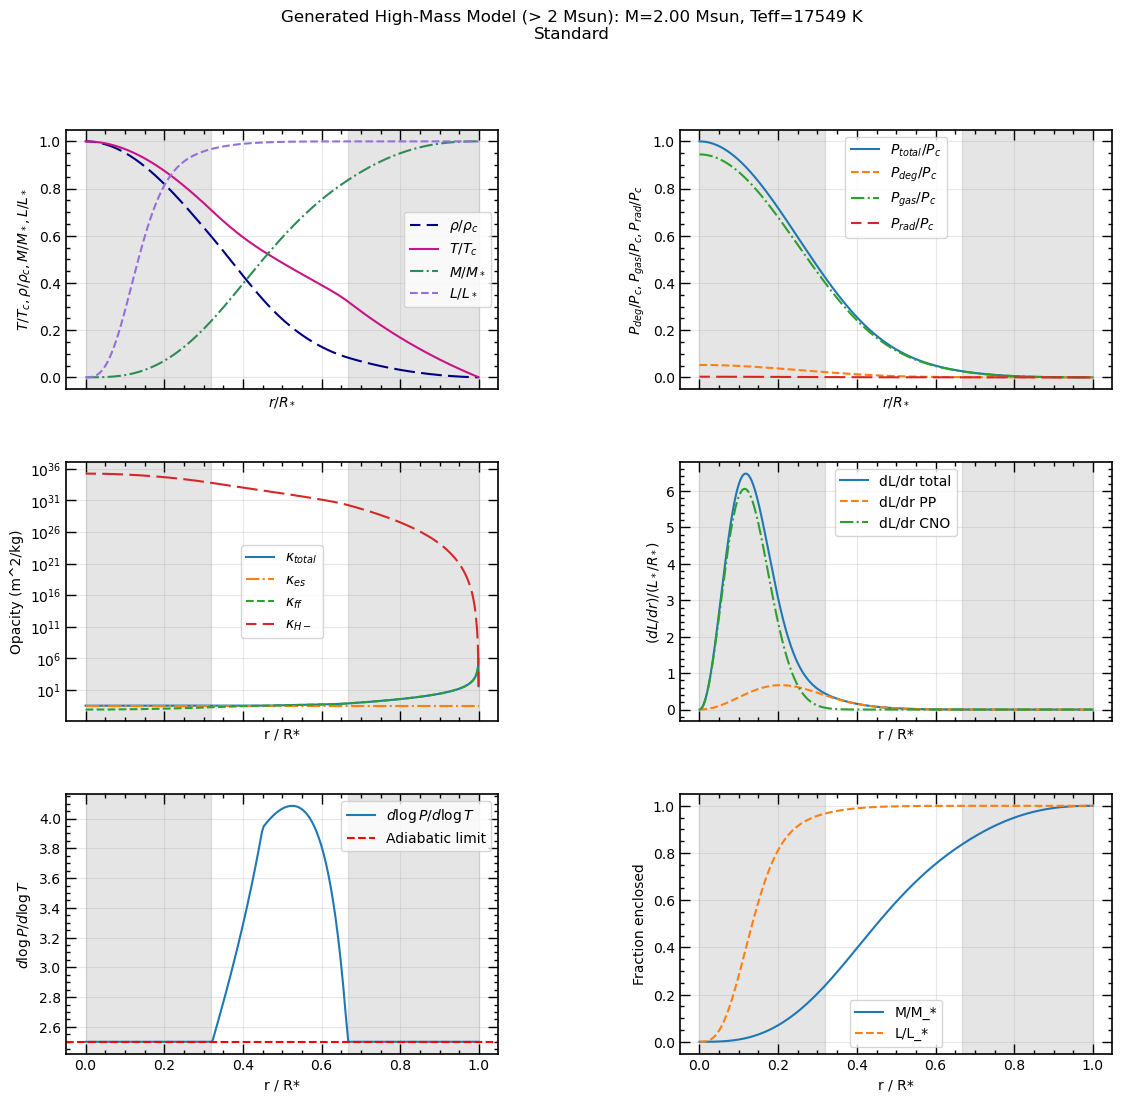


Building sequence: DM: rho0=1.0e-20 kg/m^3, m=100 GeV, s=1.25
Solving model for Tc = 4.000e+07 K
  found: M=119.591 Msun, R=7.798 Rsun, L=1.613e+07 Lsun, Teff=130984 K, rho_c=4.874e+02
Solving model for Tc = 3.240e+07 K
  found: M=25.373 Msun, R=4.609 Rsun, L=8.325e+04 Lsun, Teff=45667 K, rho_c=1.677e+03
Solving model for Tc = 3.000e+07 K
  found: M=13.130 Msun, R=3.028 Rsun, L=1.791e+04 Lsun, Teff=38374 K, rho_c=3.720e+03
Solving model for Tc = 2.624e+07 K
  found: M=5.868 Msun, R=2.234 Rsun, L=1.616e+03 Lsun, Teff=24484 K, rho_c=1.213e+04
Solving model for Tc = 2.350e+07 K
  found: M=3.164 Msun, R=1.122 Rsun, L=2.480e+02 Lsun, Teff=21624 K, rho_c=3.040e+04
Solving model for Tc = 2.125e+07 K
  found: M=2.003 Msun, R=0.760 Rsun, L=4.934e+01 Lsun, Teff=17549 K, rho_c=6.348e+04
Solving model for Tc = 2.000e+07 K
  found: M=1.695 Msun, R=0.787 Rsun, L=2.082e+01 Lsun, Teff=13899 K, rho_c=8.834e+04
Solving model for Tc = 1.900e+07 K
  found: M=1.471 Msun, R=0.642 Rsun, L=1.135e+01 Lsun, Te

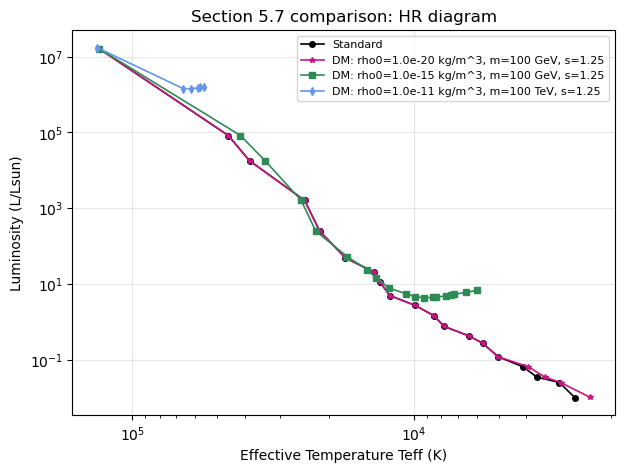

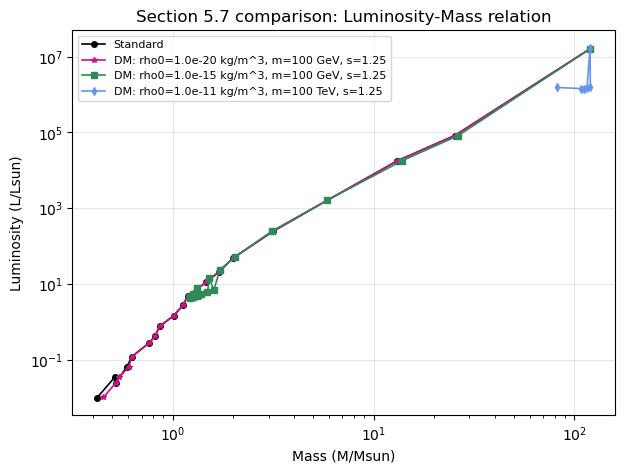

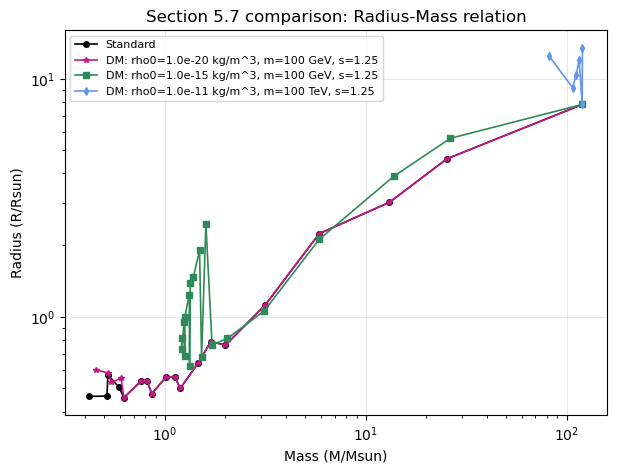

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt


# Simple main-sequence stellar structure solver
#
# The standard system of 5 equations:
#   d(rho)/dr, dT/dr, dM/dr, dL/dr, d(tau)/dr
#
# shooting method:
#   - choose central temperature Tc
#   - vary central density rho_c until the surface luminosity
#     condition L = 4*pi*sigma*R^2*T^4 is satisfied


LOW_MASS_FILENAME = "lowmass_star.txt"
HIGH_MASS_FILENAME = "highmass_star.txt"
DATA_FOLDER = os.getcwd()  # Folder containing the example .txt files

# Physical constants
G = 6.67430e-11
k_B = 1.380649e-23
hbar = 1.054571817e-34
m_e = 9.10938356e-31
m_p = 1.67262192369e-27
c = 2.99792458e8
sigma_sb = 5.670374419e-8
pi = np.pi
a_rad = 4.0 * sigma_sb / c

# Solar values for plotting
M_sun = 1.98847e30
R_sun = 6.957e8
L_sun = 3.828e26

# Composition
X = 0.70
Y = 0.28
Z = 0.02
X_CNO = 0.03 * X

# Mean molecular weight for fully ionized gas
mu = 1.0 / (2.0 * X + 0.75 * Y + 0.5 * Z)

# Adiabatic index used in convective gradient
gamma_ad = 5.0 / 3.0


# Dark matter heating configuration (project section 5.7)
PC_IN_M = 3.085677581491367e16
GEV_TO_KG = 1.78266192e-27
SECTION_57_S = 1.25
SECTION_57_SIGMA_V_DM = 3.0e-32  # m^3/s
SECTION_57_M_DM_GEV_VALUES = [1.0e2, 1.0e5]  # 100 GeV to 100 TeV
SECTION_57_RHO_DM0_VALUES = [1.0e-20, 1.0e-15, 1.0e-11]  # kg/m^3

RUN_SECTION_57_COMPARISON = True
RUN_SECTION_57_PROFILE_EXAMPLES = False
RUN_FULL_SECTION_57_GRID = False


def make_dm_config(enabled=False, s=SECTION_57_S, rho_DM0=1.0e-20,
                   m_DM_GeV=1.0e2, sigma_v_DM=SECTION_57_SIGMA_V_DM, label=None):
    """
    Package the dark-matter-heating inputs into a single dictionary so the
    stellar solver can be run either in the standard mode or in a section-5.7
    modified mode.
    """
    m_DM_kg = float(m_DM_GeV) * GEV_TO_KG
    if label is None:
        if enabled:
            tev_value = float(m_DM_GeV) / 1.0e3
            if tev_value >= 1.0:
                mass_label = f"{tev_value:.3g} TeV"
            else:
                mass_label = f"{float(m_DM_GeV):.3g} GeV"
            label = f"DM: rho0={float(rho_DM0):.1e} kg/m^3, m={mass_label}, s={float(s):.2f}"
        else:
            label = "Standard"
    return {
        'enabled': bool(enabled),
        's': float(s),
        'rho_DM0': float(rho_DM0),
        'm_DM_GeV': float(m_DM_GeV),
        'm_DM': float(m_DM_kg),
        'sigma_v_DM': float(sigma_v_DM),
        'label': label,
    }


STANDARD_DM_CONFIG = make_dm_config(enabled=False, label='Standard')


def rho_DM_profile(r, dm_config=None):
    """
    Dark-matter density profile:
    rho_DM = rho_DM,0 * (r / 1 pc)^(-s)
    """
    if dm_config is None or not dm_config.get('enabled', False):
        return 0.0
    r_safe = max(float(r), 1.0e-10)
    return dm_config['rho_DM0'] * (r_safe / PC_IN_M)**(-dm_config['s'])


def power_density_DM(r, dm_config=None):
    """
    Dark-matter annihilation power density:
    P = sigma_v * (rho_DM / m_DM)^2 * m_DM * c^2
    """
    if dm_config is None or not dm_config.get('enabled', False):
        return 0.0
    rho_dm = rho_DM_profile(r, dm_config=dm_config)
    return dm_config['sigma_v_DM'] * (rho_dm**2 / dm_config['m_DM']) * c**2


def epsilon_DM(r, rho, dm_config=None):
    """
    Specific dark-matter heating rate in W/kg.
    """
    if dm_config is None or not dm_config.get('enabled', False):
        return 0.0
    rho_safe = max(float(rho), 1.0e-30)
    return power_density_DM(r, dm_config=dm_config) / rho_safe


def build_section_57_dm_case_grid():
    """
    s fixed at 1.25, m_DM spanning 100 GeV to 100 TeV, and rho_DM,0 spanning
    1e-20 to 1e-11 kg/m^3 with a midpoint sample at 1e-15 kg/m^3.
    """
    cases = []
    for m_dm_gev in SECTION_57_M_DM_GEV_VALUES:
        for rho_dm0 in SECTION_57_RHO_DM0_VALUES:
            cases.append(
                make_dm_config(
                    enabled=True,
                    s=SECTION_57_S,
                    rho_DM0=rho_dm0,
                    m_DM_GeV=m_dm_gev,
                )
            )
    return cases


def build_representative_section_57_cases():
    """
    A lighter subset for quick runs. These still sample the required parameter
    space at the low end, middle, and upper end.
    """
    return [
        make_dm_config(enabled=True, s=SECTION_57_S, rho_DM0=1.0e-20, m_DM_GeV=1.0e2),
        make_dm_config(enabled=True, s=SECTION_57_S, rho_DM0=1.0e-15, m_DM_GeV=1.0e2),
        make_dm_config(enabled=True, s=SECTION_57_S, rho_DM0=1.0e-11, m_DM_GeV=1.0e5),
    ]


# Helpful functions


def pressure_total(rho, T):
    """Total pressure = degeneracy + ideal gas + radiation."""
    # Non-relativistic electron degeneracy pressure
    P_deg = ((3.0 * pi**2)**(2.0 / 3.0) / 5.0) * (hbar**2 / m_e) * (rho / m_p)**(5.0 / 3.0)

    # Ideal gas pressure
    P_gas = rho * k_B * T / (mu * m_p)

    # Radiation pressure
    P_rad = (1.0 / 3.0) * a_rad * T**4

    return P_deg + P_gas + P_rad


def pressure_parts(rho, T):
    """Return pressure pieces separately for plotting."""
    P_deg = ((3.0 * pi**2)**(2.0 / 3.0) / 5.0) * (hbar**2 / m_e) * (rho / m_p)**(5.0 / 3.0)
    P_gas = rho * k_B * T / (mu * m_p)
    P_rad = (1.0 / 3.0) * a_rad * T**4
    return P_deg, P_gas, P_rad


def dP_drho(rho, T):
    """Partial derivative dP/drho at fixed T."""
    term_deg = ((3.0 * pi**2)**(2.0 / 3.0) / 3.0) * (hbar**2 / (m_e * m_p)) * (rho / m_p)**(2.0 / 3.0)
    term_gas = k_B * T / (mu * m_p)
    return term_deg + term_gas


def dP_dT(rho, T):
    """Partial derivative dP/dT at fixed rho."""
    term_gas = rho * k_B / (mu * m_p)
    term_rad = (4.0 / 3.0) * a_rad * T**3
    return term_gas + term_rad


def epsilon_pp(rho, T):
    """PP-chain energy generation in W/kg."""
    rho5 = rho / 1.0e5
    T6 = T / 1.0e6
    if T6 <= 0:
        return 0.0
    return 1.07e-7 * rho5 * X**2 * T6**4


def epsilon_cno(rho, T):
    """CNO-cycle energy generation in W/kg."""
    rho5 = rho / 1.0e5
    T6 = T / 1.0e6
    if T6 <= 0:
        return 0.0
    return 8.24e-26 * rho5 * X * X_CNO * T6**19.9


def epsilon_total(r, rho, T, dm_config=None):
    """Total specific energy generation, including optional dark-matter heating."""
    return epsilon_pp(rho, T) + epsilon_cno(rho, T) + epsilon_DM(r, rho, dm_config=dm_config)


def opacity_parts(rho, T):
    """Return kappa_es, kappa_ff, kappa_Hminus separately."""
    rho3 = max(rho / 1.0e3, 1.0e-30)
    T = max(T, 1.0)

    k_es = 0.02 * (1.0 + X)
    k_ff = 1.0e24 * (Z + 0.0001) * rho3**0.7 * T**(-3.5)
    k_hm = 2.5e-32 * (Z / 0.02) * rho3**0.5 * T**9
    return k_es, k_ff, k_hm


def opacity_total(rho, T):
    """Combined opacity formula."""
    k_es, k_ff, k_hm = opacity_parts(rho, T)
    k_highT = max(k_es, k_ff)
    # Smooth combination that switches to H- near the surface
    return 1.0 / (1.0 / max(k_hm, 1.0e-40) + 1.0 / max(k_highT, 1.0e-40))



def effective_temperature_from_surface(surface):
    """Compute Teff from luminosity and radius using Stefan-Boltzmann."""
    radius = max(surface['r'], 1.0e-30)
    luminosity = max(surface['L'], 0.0)
    return (luminosity / (4.0 * pi * sigma_sb * radius**2))**0.25


def get_surface_teff(surface):
    """Return Teff if stored; otherwise compute it from L and R."""
    if surface is None:
        return np.nan
    if 'Teff' in surface and np.isfinite(surface['Teff']):
        return surface['Teff']
    return effective_temperature_from_surface(surface)


def convective_from_dlogP_dlogT(dlogP_dlogT):
    """Approximate convective zones from the tabulated stability ratio."""
    threshold = gamma_ad / (gamma_ad - 1.0)
    return dlogP_dlogT <= threshold + 1.0e-8


def load_reference_star_file(file_path, label):
    """Load one example-star text file and convert cgs columns to SI units."""
    raw = np.loadtxt(file_path, comments='#')

    # Convert the columns used by the plots from cgs to SI.
    r = raw[:, 1] * 1.0e-2
    rho = raw[:, 2] * 1.0e3
    T = raw[:, 3]
    M_r = raw[:, 4] * 1.0e-3
    L_r = raw[:, 5] * 1.0e-7
    dLdr = raw[:, 6] * 1.0e-5
    dLppdr = raw[:, 7] * 1.0e-5
    dLcnodr = raw[:, 8] * 1.0e-5
    dlogP_dlogT = raw[:, 9]

    kappa = raw[:, 15] * 0.1
    k_hm = raw[:, 16] * 0.1
    k_ff = raw[:, 17] * 0.1
    k_es = raw[:, 18] * 0.1

    P = raw[:, 19] * 0.1
    P_deg = raw[:, 20] * 0.1
    P_gas = raw[:, 21] * 0.1
    P_rad = raw[:, 22] * 0.1

    shell_factor = 4.0 * pi * np.maximum(r, 1.0)**2 * np.maximum(rho, 1.0e-30)
    eps_pp = dLppdr / shell_factor
    eps_cno = dLcnodr / shell_factor

    model = {
        'label': label,
        'r': r,
        'rho': rho,
        'T': T,
        'M': M_r,
        'L': L_r,
        'P': P,
        'P_deg': P_deg,
        'P_gas': P_gas,
        'P_rad': P_rad,
        'kappa': kappa,
        'k_es': k_es,
        'k_ff': k_ff,
        'k_hm': k_hm,
        'dLdr': dLdr,
        'eps_pp': eps_pp,
        'eps_cno': eps_cno,
        'dlogP_dlogT': dlogP_dlogT,
        'convective': convective_from_dlogP_dlogT(dlogP_dlogT),
        'surface': {
            'r': r[-1],
            'rho': rho[-1],
            'T': T[-1],
            'M': M_r[-1],
            'L': L_r[-1],
        },
    }
    model['surface']['Teff'] = effective_temperature_from_surface(model['surface'])
    return model


def load_example_stars_once(data_folder):
    """Load the low-mass and high-mass example files."""
    low_path = os.path.join(data_folder, LOW_MASS_FILENAME)
    high_path = os.path.join(data_folder, HIGH_MASS_FILENAME)

    if not os.path.exists(low_path):
        raise FileNotFoundError(f'Could not find {low_path}')
    if not os.path.exists(high_path):
        raise FileNotFoundError(f'Could not find {high_path}')

    example_stars = {
        'low': load_reference_star_file(low_path, 'Low-Mass Reference Star'),
        'high': load_reference_star_file(high_path, 'High-Mass Reference Star'),
    }
    return example_stars

def safe_dlogP_dlogT_from_model(model):
    """Return a robust dlogP/dlogT profile without using np.gradient on duplicate radii."""
    if 'dlogP_dlogT' in model:
        values = np.asarray(model['dlogP_dlogT'], dtype=float)
        if values.shape == np.asarray(model['r']).shape:
            return values

    r = np.asarray(model['r'], dtype=float)
    P = np.asarray(model['P'], dtype=float)
    T = np.asarray(model['T'], dtype=float)

    # Keep only strictly increasing radius samples for finite differencing.
    keep = np.ones(len(r), dtype=bool)
    if len(r) > 1:
        keep[1:] = np.diff(r) > 0.0

    r_u = r[keep]
    P_u = P[keep]
    T_u = T[keep]

    if len(r_u) < 3:
        return np.full_like(r, np.nan, dtype=float)

    dPdr_u = np.gradient(P_u, r_u)
    dTdr_u = np.gradient(T_u, r_u)

    out_u = np.full_like(r_u, np.nan, dtype=float)
    good = (np.abs(dTdr_u) > 1.0e-99) & (np.abs(P_u) > 1.0e-99)
    out_u[good] = (T_u[good] / P_u[good]) * dPdr_u[good] / dTdr_u[good]

    out = np.full_like(r, np.nan, dtype=float)
    out[keep] = out_u
    return out


# ODE system
# state = [rho, T, M, L, tau]

def stellar_derivatives(r, state, dm_config=None):
    rho, T, M, L, tau = state

    # Prevent non-physical negative values during integration
    rho = max(rho, 1.0e-12)
    T = max(T, 1.0)
    M = max(M, 1.0e-30)
    r = max(r, 1.0)

    P = pressure_total(rho, T)
    kappa = opacity_total(rho, T)
    eps = epsilon_total(r, rho, T, dm_config=dm_config)

    # Radiative temperature gradient
    dTdr_rad = -(3.0 * kappa * rho * L) / (16.0 * pi * a_rad * c * T**3 * r**2)

    # Convective temperature gradient
    dTdr_conv = -((1.0 - 1.0 / gamma_ad) * T / P) * (G * M * rho / r**2)

    if abs(dTdr_rad) < abs(dTdr_conv):
        dTdr = dTdr_rad
    else:
        dTdr = dTdr_conv

    dp_rho = dP_drho(rho, T)
    dp_T = dP_dT(rho, T)
    drhodr = -(G * M * rho / r**2 + dp_T * dTdr) / dp_rho

    dMdr = 4.0 * pi * r**2 * rho
    dLdr = 4.0 * pi * r**2 * rho * eps
    dtaudr = kappa * rho

    return np.array([drhodr, dTdr, dMdr, dLdr, dtaudr], dtype=float)


def rk4_step(r, y, h, dm_config=None):
    """One RK4 step."""
    k1 = stellar_derivatives(r, y, dm_config=dm_config)
    k2 = stellar_derivatives(r + 0.5 * h, y + 0.5 * h * k1, dm_config=dm_config)
    k3 = stellar_derivatives(r + 0.5 * h, y + 0.5 * h * k2, dm_config=dm_config)
    k4 = stellar_derivatives(r + h, y + h * k3, dm_config=dm_config)
    return y + (h / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)


def interpolate_surface_from_tau(history):
    """
    Estimate the stellar photosphere using the optical-depth condition.

    Method:
    - work with remaining optical depth to infinity
    - interpolate in log(remaining optical depth), which is more natural
      for the steep outer atmosphere
    - allow a small final extrapolation if the photosphere lies just
      beyond the last grid point
    """
    r = history['r']
    rho = history['rho']
    T = history['T']
    M = history['M']
    L = history['L']
    tau = history['tau']

    if len(r) < 2:
        return None

    target_remaining_tau = 2.0 / 3.0

    # Estimate remaining optical depth beyond the final grid point
    tau_end = tau[-1]
    delta_tau_remaining = 0.0
    H_rho_end = None

    dr_end = r[-1] - r[-2]
    if dr_end > 0:
        rho_end = max(rho[-1], 1.0e-30)
        T_end = max(T[-1], 1.0)
        drhodr_end = (rho[-1] - rho[-2]) / dr_end

        if drhodr_end < -1.0e-40:
            H_rho_end = rho_end / abs(drhodr_end)
            kappa_end = opacity_total(rho_end, T_end)
            delta_tau_remaining = kappa_end * rho_end * H_rho_end

            if not np.isfinite(delta_tau_remaining) or delta_tau_remaining < 0.0:
                delta_tau_remaining = 0.0
        else:
            H_rho_end = max(dr_end, 1.0)

    tau_infinity_est = tau_end + delta_tau_remaining

    # Remaining optical depth outside each radius point
    tau_remaining = tau_infinity_est - tau

    # Case 1: surface lies inside the computed grid
    if tau_remaining[0] > target_remaining_tau and tau_remaining[-1] <= target_remaining_tau:
        j = np.where(tau_remaining <= target_remaining_tau)[0][0]
        i = j - 1

        rem0 = max(tau_remaining[i], 1.0e-300)
        rem1 = max(tau_remaining[i + 1], 1.0e-300)

        # Log interpolation in remaining optical depth
        if rem0 != rem1:
            frac = (
                np.log(target_remaining_tau) - np.log(rem0)
            ) / (
                np.log(rem1) - np.log(rem0)
            )
        else:
            frac = 0.0

        frac = min(max(frac, 0.0), 1.0)

        def interp(arr):
            return arr[i] + frac * (arr[i + 1] - arr[i])

        surface = {
            'r': interp(r),
            'rho': interp(rho),
            'T': interp(T),
            'M': interp(M),
            'L': interp(L),
            'tau': tau_infinity_est - target_remaining_tau,
            'tau_end': tau_end,
            'tau_infinity_est': tau_infinity_est,
            'delta_tau_remaining': delta_tau_remaining,
            'tau_remaining_surface': target_remaining_tau,
            'index': i,
            'frac': frac,
        }
        return surface

    # Case 2: surface lies just beyond the last computed point
    if tau_remaining[-1] > target_remaining_tau and delta_tau_remaining > target_remaining_tau:
        rho_end = max(rho[-1], 1.0e-30)
        T_end = max(T[-1], 1.0)

        if H_rho_end is None or H_rho_end <= 0.0:
            H_rho_end = max(dr_end, 1.0)

        delta_r = H_rho_end * np.log(delta_tau_remaining / target_remaining_tau)

        # Keep extrapolation modest and stable
        delta_r = min(max(delta_r, 0.0), 3.0 * H_rho_end)

        r_surface = r[-1] + delta_r
        rho_surface = rho_end * np.exp(-delta_r / H_rho_end)

        surface = {
            'r': r_surface,
            'rho': rho_surface,
            'T': T[-1],
            'M': M[-1],
            'L': L[-1],
            'tau': tau_infinity_est - target_remaining_tau,
            'tau_end': tau_end,
            'tau_infinity_est': tau_infinity_est,
            'delta_tau_remaining': delta_tau_remaining,
            'tau_remaining_surface': target_remaining_tau,
            'index': len(r) - 2,
            'frac': 1.0,
        }
        return surface

    # Fallback: use the last point if something unusual happens
    return {
        'r': r[-1],
        'rho': rho[-1],
        'T': T[-1],
        'M': M[-1],
        'L': L[-1],
        'tau': tau[-1],
        'tau_end': tau_end,
        'tau_infinity_est': tau_infinity_est,
        'delta_tau_remaining': delta_tau_remaining,
        'tau_remaining_surface': tau_remaining[-1],
        'index': len(r) - 2,
        'frac': 1.0,
    }


def choose_step_size(r, T):
    """
    Small steps near the surface so the photosphere is resolved better.
    """
    if T > 1.0e6:
        frac = 0.01      # deep interior
    elif T > 1.0e5:
        frac = 0.003     # intermediate layers
    else:
        frac = 0.0005    # outer envelope / near photosphere

    return max(1.0e3, frac * r)


# Solve one trial star for fixed rho_c and T_c

def integrate_star(rho_c, T_c, max_steps=200000, dm_config=None):
    """
    Integrate outward from a small starting radius r0.
    """
    if dm_config is None:
        dm_config = STANDARD_DM_CONFIG

    r0 = 1.0e3

    eps_c = epsilon_total(r0, rho_c, T_c, dm_config=dm_config)
    M0 = (4.0 / 3.0) * pi * r0**3 * rho_c
    L0 = (4.0 / 3.0) * pi * r0**3 * rho_c * eps_c
    y = np.array([rho_c, T_c, M0, L0, 0.0], dtype=float)

    r_list = [r0]
    rho_list = [y[0]]
    T_list = [y[1]]
    M_list = [y[2]]
    L_list = [y[3]]
    tau_list = [y[4]]

    converged_outer = False

    r = r0
    for _ in range(max_steps):
        h = choose_step_size(r, y[1])
        y_new = rk4_step(r, y, h, dm_config=dm_config)

        if y_new[0] <= 0 or y_new[1] <= 0 or np.any(np.isnan(y_new)) or np.any(np.isinf(y_new)):
            break

        r = r + h
        y = y_new

        r_list.append(r)
        rho_list.append(y[0])
        T_list.append(y[1])
        M_list.append(y[2])
        L_list.append(y[3])
        tau_list.append(y[4])

        derivs = stellar_derivatives(r, y, dm_config=dm_config)
        drhodr = derivs[0]
        rho = max(y[0], 1.0e-30)
        T = max(y[1], 1.0)
        kappa = opacity_total(rho, T)

        if abs(drhodr) > 1.0e-40:
            delta_tau = kappa * rho**2 / abs(drhodr)
        else:
            delta_tau = 1.0e99

        if delta_tau < 1.0e-3 and T < 2.0e4:
            converged_outer = True
            break

        if y[2] > 1000.0 * M_sun:
            break
        if r > 200.0 * R_sun:
            break

    history = {
        'r': np.array(r_list),
        'rho': np.array(rho_list),
        'T': np.array(T_list),
        'M': np.array(M_list),
        'L': np.array(L_list),
        'tau': np.array(tau_list),
        'outer_ok': converged_outer,
        'dm_config': dict(dm_config),
        'dm_enabled': bool(dm_config.get('enabled', False)),
    }

    if len(history['r']) < 3:
        return None

    surface = interpolate_surface_from_tau(history)

    P_tot = []
    P_deg_list = []
    P_gas_list = []
    P_rad_list = []
    kappa_list = []
    k_es_list = []
    k_ff_list = []
    k_hm_list = []
    rho_dm_list = []
    power_dm_list = []
    eps_pp_list = []
    eps_cno_list = []
    eps_dm_list = []
    eps_total_list = []
    dLdr_pp_list = []
    dLdr_cno_list = []
    dLdr_dm_list = []
    dLdr_list = []
    dTdr_list = []
    dlogP_dlogT_list = []
    convective_flag = []

    for i in range(len(history['r'])):
        rr = history['r'][i]
        rho = history['rho'][i]
        T = history['T'][i]
        M = history['M'][i]
        L = history['L'][i]

        P = pressure_total(rho, T)
        P_deg, P_gas, P_rad = pressure_parts(rho, T)
        k_es, k_ff, k_hm = opacity_parts(rho, T)
        kappa = opacity_total(rho, T)

        rho_dm_val = rho_DM_profile(rr, dm_config=dm_config)
        power_dm_val = power_density_DM(rr, dm_config=dm_config)
        eps_pp_val = epsilon_pp(rho, T)
        eps_cno_val = epsilon_cno(rho, T)
        eps_dm_val = epsilon_DM(rr, rho, dm_config=dm_config)
        eps_total_val = eps_pp_val + eps_cno_val + eps_dm_val

        dLdr_pp = 4.0 * pi * rr**2 * rho * eps_pp_val
        dLdr_cno = 4.0 * pi * rr**2 * rho * eps_cno_val
        dLdr_dm = 4.0 * pi * rr**2 * rho * eps_dm_val
        dLdr = dLdr_pp + dLdr_cno + dLdr_dm

        dTdr_rad = -(3.0 * kappa * rho * L) / (16.0 * pi * a_rad * c * T**3 * rr**2)
        dTdr_conv = -((1.0 - 1.0 / gamma_ad) * T / P) * (G * M * rho / rr**2)
        dTdr_val = dTdr_rad if abs(dTdr_rad) < abs(dTdr_conv) else dTdr_conv
        is_convective = abs(dTdr_conv) <= abs(dTdr_rad)
        dPdr_val = -(G * M * rho / max(rr, 1.0)**2)
        if abs(dTdr_val) > 1.0e-99 and abs(P) > 1.0e-99:
            dlogP_dlogT_val = (T / P) * dPdr_val / dTdr_val
        else:
            dlogP_dlogT_val = np.nan

        P_tot.append(P)
        P_deg_list.append(P_deg)
        P_gas_list.append(P_gas)
        P_rad_list.append(P_rad)
        kappa_list.append(kappa)
        k_es_list.append(k_es)
        k_ff_list.append(k_ff)
        k_hm_list.append(k_hm)
        rho_dm_list.append(rho_dm_val)
        power_dm_list.append(power_dm_val)
        eps_pp_list.append(eps_pp_val)
        eps_cno_list.append(eps_cno_val)
        eps_dm_list.append(eps_dm_val)
        eps_total_list.append(eps_total_val)
        dLdr_pp_list.append(dLdr_pp)
        dLdr_cno_list.append(dLdr_cno)
        dLdr_dm_list.append(dLdr_dm)
        dLdr_list.append(dLdr)
        dTdr_list.append(dTdr_val)
        dlogP_dlogT_list.append(dlogP_dlogT_val)
        convective_flag.append(is_convective)

    history['P'] = np.array(P_tot)
    history['P_deg'] = np.array(P_deg_list)
    history['P_gas'] = np.array(P_gas_list)
    history['P_rad'] = np.array(P_rad_list)
    history['kappa'] = np.array(kappa_list)
    history['k_es'] = np.array(k_es_list)
    history['k_ff'] = np.array(k_ff_list)
    history['k_hm'] = np.array(k_hm_list)
    history['rho_dm'] = np.array(rho_dm_list)
    history['power_dm'] = np.array(power_dm_list)
    history['eps_pp'] = np.array(eps_pp_list)
    history['eps_cno'] = np.array(eps_cno_list)
    history['eps_dm'] = np.array(eps_dm_list)
    history['eps_total'] = np.array(eps_total_list)
    history['dLdr_pp'] = np.array(dLdr_pp_list)
    history['dLdr_cno'] = np.array(dLdr_cno_list)
    history['dLdr_dm'] = np.array(dLdr_dm_list)
    history['dLdr'] = np.array(dLdr_list)
    history['dTdr'] = np.array(dTdr_list)
    history['dlogP_dlogT'] = np.array(dlogP_dlogT_list)
    history['convective'] = np.array(convective_flag, dtype=bool)

    if surface is not None:
        surface['Teff'] = get_surface_teff(surface)
    history['surface'] = surface

    return history


def luminosity_surface_error(rho_c, T_c, dm_config=None):
    """
    Return the mismatch function used in the shooting method.
    Root of this function corresponds to a star satisfying
    L(R*) = 4*pi*sigma*R*^2*T*^4
    """
    result = integrate_star(rho_c, T_c, dm_config=dm_config)
    if result is None:
        return None, None

    R_star = result['surface']['r']
    T_star = result['surface']['T']
    L_star = result['surface']['L']

    L_photo = 4.0 * pi * sigma_sb * R_star**2 * T_star**4

    denom = np.sqrt(max(L_star * L_photo, 1.0e-60))
    error = (L_star - L_photo) / denom

    return error, result


def solve_star_for_Tc(T_c, rho_guess=None, mass_guess=None, dm_config=None):
    """
    Solve for the central density rho_c at a chosen central temperature T_c.

    This version keeps the numerical safeguards from the filtered notebook,
    but it ranks candidate roots instead of discarding most of them. That
    helps preserve solutions for the provided Tc grid when dark-matter heating
    shifts the branch away from the standard main sequence.
    """
    if dm_config is None:
        dm_config = STANDARD_DM_CONFIG

    rho_min = 1.0e2
    rho_max = 1.0e7

    def get_error_value(result):
        if result is None:
            return None

        if isinstance(result, (tuple, list)):
            if len(result) == 0:
                return None
            result = result[0]

        try:
            result = float(result)
        except (TypeError, ValueError):
            return None

        if not np.isfinite(result):
            return None

        return result

    def local_rho_grid(center):
        rho_low = max(rho_min, center / 20.0)
        rho_high = min(rho_max, center * 20.0)

        if rho_low >= rho_high:
            return np.array([center], dtype=float)

        return np.logspace(np.log10(rho_low), np.log10(rho_high), 41)

    def global_rho_grid():
        return np.logspace(np.log10(rho_min), np.log10(rho_max), 120)

    def candidate_is_numerically_valid(model):
        if model is None or 'surface' not in model or model['surface'] is None:
            return False

        s = model['surface']
        values = [s.get('r', np.nan), s.get('M', np.nan), s.get('L', np.nan), s.get('T', np.nan), get_surface_teff(s)]
        if not np.all(np.isfinite(values)):
            return False

        if s['r'] <= 0.0 or s['M'] <= 0.0 or s['L'] <= 0.0 or s['T'] <= 0.0:
            return False

        return True

    def candidate_quality_penalty(model):
        """
        Soft penalty for ranking branches. We prefer models that cleanly reach
        the photosphere and look main-sequence-like, but we do not reject them
        outright unless they are numerically invalid.
        """
        if not candidate_is_numerically_valid(model):
            return np.inf

        s = model['surface']
        teff = get_surface_teff(s)
        radius_rsun = s['r'] / R_sun
        penalty = 0.0

        tau_rem = float(s.get('tau_remaining_surface', np.nan))
        if model.get('outer_ok', False):
            penalty += 0.0
        elif np.isfinite(tau_rem):
            penalty += min(3.0, 0.5 * abs(np.log10(max(tau_rem, 1.0e-12) / (2.0 / 3.0))))
        else:
            penalty += 3.0

        if np.isfinite(teff):
            if teff < 1200.0:
                penalty += 0.5 * abs(np.log10(1200.0 / max(teff, 1.0)))
            elif teff > 5.0e5:
                penalty += 0.5 * abs(np.log10(teff / 5.0e5))

        if radius_rsun > 100.0:
            penalty += 0.2 * np.log10(radius_rsun / 100.0)

        return penalty

    def scan_rho_grid(rho_values):
        brackets = []
        best_trial = None
        prev_rho = None
        prev_err = None

        for rho in rho_values:
            err, trial_model = luminosity_surface_error(rho, T_c, dm_config=dm_config)
            err = get_error_value(err)

            if err is None:
                continue

            if trial_model is not None and candidate_is_numerically_valid(trial_model):
                abs_err = abs(err)
                score = abs_err + 0.05 * candidate_quality_penalty(trial_model)
                if best_trial is None or score < best_trial[0]:
                    best_trial = (score, abs_err, rho, trial_model)

            if prev_err is not None and prev_err * err < 0:
                brackets.append((prev_rho, rho))

            prev_rho = rho
            prev_err = err

        return brackets, best_trial

    def refine_bracket(a, b):
        fa = get_error_value(luminosity_surface_error(a, T_c, dm_config=dm_config)[0])
        fb = get_error_value(luminosity_surface_error(b, T_c, dm_config=dm_config)[0])

        if fa is None or fb is None:
            return None, None

        best_mid = None
        best_abs_f = None

        for _ in range(80):
            mid = np.sqrt(a * b)
            fm, _ = luminosity_surface_error(mid, T_c, dm_config=dm_config)
            fm = get_error_value(fm)

            if fm is None:
                return None, None

            if best_abs_f is None or abs(fm) < best_abs_f:
                best_abs_f = abs(fm)
                best_mid = mid

            if abs(fm) < 1.0e-3 or abs(np.log10(b / a)) < 1.0e-4:
                break

            if fa * fm < 0:
                b = mid
                fb = fm
            else:
                a = mid
                fa = fm

        rho_best = best_mid if best_mid is not None else np.sqrt(a * b)
        model = integrate_star(rho_best, T_c, dm_config=dm_config)
        if not candidate_is_numerically_valid(model):
            return None, None
        return model, rho_best

    candidate_brackets = []
    best_trials = []

    if rho_guess is not None:
        local_brackets, local_best = scan_rho_grid(local_rho_grid(rho_guess))
        candidate_brackets.extend(local_brackets)
        if local_best is not None:
            best_trials.append(local_best)

    global_brackets, global_best = scan_rho_grid(global_rho_grid())
    candidate_brackets.extend(global_brackets)
    if global_best is not None:
        best_trials.append(global_best)

    unique_brackets = []
    seen = set()
    for a, b in candidate_brackets:
        key = (round(np.log10(a), 4), round(np.log10(b), 4))
        if key not in seen:
            seen.add(key)
            unique_brackets.append((a, b))

    candidates = []
    for a, b in unique_brackets:
        model, rho_solution = refine_bracket(a, b)
        if model is not None:
            candidates.append((model, rho_solution))

    # If no clean bracket survives, fall back to the best near-root trial.
    if len(candidates) == 0 and len(best_trials) > 0:
        best_trials.sort(key=lambda item: (item[0], item[1]))
        _, abs_err, rho_solution, model = best_trials[0]
        if abs_err < 0.15:
            return model, rho_solution
        return None, None

    if len(candidates) == 0:
        return None, None

    def candidate_selection_score(model, rho_solution):
        score = candidate_quality_penalty(model)

        if mass_guess is not None:
            M_model = model['surface']['M']
            if M_model > 0.0:
                score += abs(np.log10(M_model / mass_guess))
            else:
                score += 10.0

        if rho_guess is not None and rho_solution > 0.0:
            score += 0.12 * abs(np.log10(rho_solution / rho_guess))

        if mass_guess is None:
            s = model['surface']
            score += 0.05 * (s['r'] / max(s['M'], 1.0e-60))

        return score

    best_model = None
    best_rho = None
    best_score = None

    for model, rho_solution in candidates:
        score = candidate_selection_score(model, rho_solution)
        if best_score is None or score < best_score:
            best_score = score
            best_model = model
            best_rho = rho_solution

    return best_model, best_rho


def build_main_sequence(Tc_values, dm_config=None, verbose=True):
    """
    Build the main-sequence models by starting at high Tc and stepping
    downward, using both previous rho_c and previous mass to stay on
    one smooth physical branch.
    """
    if dm_config is None:
        dm_config = STANDARD_DM_CONFIG

    models = []

    Tc_values = np.array(sorted(Tc_values, reverse=True), dtype=float)

    previous_rho_c = None
    previous_mass = None

    if verbose:
        print(f"\nBuilding sequence: {dm_config['label']}")

    for Tc in Tc_values:
        if verbose:
            print(f"Solving model for Tc = {Tc:.3e} K")

        model, rho_solution = solve_star_for_Tc(
            Tc,
            rho_guess=previous_rho_c,
            mass_guess=previous_mass,
            dm_config=dm_config
        )

        if model is not None:
            model['sequence_label'] = dm_config['label']
            models.append(model)
            previous_rho_c = rho_solution
            previous_mass = model['surface']['M']

            if verbose:
                s = model['surface']
                print(
                    "  found: "
                    f"M={s['M']/M_sun:.3f} Msun, "
                    f"R={s['r']/R_sun:.3f} Rsun, "
                    f"L={s['L']/L_sun:.3e} Lsun, "
                    f"Teff={get_surface_teff(s):.0f} K, "
                    f"rho_c={rho_solution:.3e}"
                )
        else:
            if verbose:
                print("  no solution found")

    return models


def select_generated_high_mass_model(models, min_mass_msun=2.0):
    """
    Choose a generated stellar model above the required mass threshold.

    We pick the model whose mass is the smallest value still above the
    threshold so it is the closest match to the project requirement
    without jumping to an unnecessarily extreme star.
    """
    candidates = [m for m in models if m['surface']['M'] / M_sun > min_mass_msun]

    if len(candidates) == 0:
        raise ValueError(f'No generated stellar model above {min_mass_msun:.1f} Msun was found.')

    return min(candidates, key=lambda m: (m['surface']['M'] / M_sun) - min_mass_msun)



# Plotting helpers

def annotate_example_points(ax, x_low, y_low, x_high, y_high):
    """Add separate labels for the low-mass and high-mass stars."""
    ax.annotate('Low-mass star', xy=(x_low, y_low), xytext=(8, 8),
                textcoords='offset points')
    ax.annotate('High-mass star', xy=(x_high, y_high), xytext=(8, -12),
                textcoords='offset points')


def plot_main_sequence(models, example_stars=None):
    masses = np.array([m['surface']['M'] / M_sun for m in models])
    radii = np.array([m['surface']['r'] / R_sun for m in models])
    luminosities = np.array([m['surface']['L'] / L_sun for m in models])
    teff = np.array([effective_temperature_from_surface(m['surface']) for m in models])

    # HR diagram
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(teff, luminosities,marker= '*',s=30,color='mediumvioletred', label='Solved sequence')

    if example_stars is not None:
        low_teff = example_stars['low']['surface']['Teff']
        high_teff = example_stars['high']['surface']['Teff']
        low_lum = example_stars['low']['surface']['L'] / L_sun
        high_lum = example_stars['high']['surface']['L'] / L_sun
        ax.scatter(low_teff, low_lum, marker='d', color = 'cornflowerblue', label='Low-mass star', zorder=2)
        ax.scatter(high_teff, high_lum, marker='o', color = 'seagreen', label='High-mass star', zorder=2)
        annotate_example_points(ax, low_teff, low_lum, high_teff, high_lum)

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.invert_xaxis()
    ax.set_xlabel('Effective Temperature Teff (K)')
    ax.set_ylabel('Luminosity (L/Lsun)')
    ax_top = ax.twiny()
    ax_top.set_xlim(ax.get_xlim())
    ax_top.set_xscale('log')            
        
    spectral_teff = [30000, 20000, 10000, 7000, 5500, 4500, 3200]
    spectral_labels = ['O', 'B', 'A', 'F', 'G', 'K', 'M']
    
    ax_top.set_xticks(spectral_teff)
    ax_top.tick_params(direction='in')
    ax_top.set_xticklabels(spectral_labels)
    ax_top.set_xlabel('Spectral Type')
    ax.set_title('Model HR Diagram')
    ax.grid(True, alpha=0.3)
    if example_stars is not None:
        ax.legend()
    plt.show()

    # L-M relation
    fig, ax = plt.subplots(figsize=(7, 5))
    idx = np.argsort(masses)
    ax.plot(masses[idx], luminosities[idx], '*-',color='mediumvioletred', label='Solved sequence')
    if example_stars is not None:
        low_mass = example_stars['low']['surface']['M'] / M_sun
        high_mass = example_stars['high']['surface']['M'] / M_sun
        low_lum = example_stars['low']['surface']['L'] / L_sun
        high_lum = example_stars['high']['surface']['L'] / L_sun
        ax.scatter(low_mass, low_lum, marker='d', color = 'cornflowerblue', label='Low-mass star', zorder=2)
        ax.scatter(high_mass, high_lum, marker='o', color = 'seagreen', label='High-mass star', zorder=2)
        annotate_example_points(ax, low_mass, low_lum, high_mass, high_lum)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Mass (M/Msun)')
    ax.set_ylabel('Luminosity (L/Lsun)')
    ax.set_title('Luminosity-Mass Relation')
    ax.grid(True, alpha=0.3)
    if example_stars is not None:
        ax.legend()
    plt.show()

    # R-M relation
    fig, ax = plt.subplots(figsize=(7, 5))
    idx = np.argsort(masses)
    ax.plot(masses[idx], radii[idx], 'o-',color='mediumvioletred', label='Solved sequence')
    if example_stars is not None:
        low_mass = example_stars['low']['surface']['M'] / M_sun
        high_mass = example_stars['high']['surface']['M'] / M_sun
        low_radius = example_stars['low']['surface']['r'] / R_sun
        high_radius = example_stars['high']['surface']['r'] / R_sun
        ax.scatter(low_mass, low_radius, marker='d', color = 'cornflowerblue', label='Low-mass star', zorder=2)
        ax.scatter(high_mass, high_radius, marker='o', color = 'seagreen', label='High-mass star', zorder=2)
        annotate_example_points(ax, low_mass, low_radius, high_mass, high_radius)
    ax.minorticks_on()
    ax.tick_params(which='major', length=7, width=1, direction='in')
    ax.tick_params(which='minor', length=7, width=1, direction='in')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Mass (M/Msun)')
    ax.set_ylabel('Radius (R/Rsun)')
    ax.set_title('Radius-Mass Relation')
    ax.grid(True, alpha=0.3)
    if example_stars is not None:
        ax.legend()
    plt.show()


def plot_main_sequence_comparison(sequence_entries):
    """
    Overlay multiple main-sequence runs (standard and dark-matter-heated cases)
    so the section-5.7 impact on the HR diagram, L-M relation, and R-M relation
    can be inspected directly.
    """
    palette = ['black', 'mediumvioletred', 'seagreen', 'cornflowerblue', 'darkorange', 'mediumpurple', 'firebrick']
    markers = ['o', '*', 's', 'd', '^', 'v', 'P']

    # HR diagram
    fig, ax = plt.subplots(figsize=(7, 5))
    for idx, entry in enumerate(sequence_entries):
        models = entry['models']
        if len(models) == 0:
            continue
        masses = np.array([m['surface']['M'] / M_sun for m in models])
        luminosities = np.array([m['surface']['L'] / L_sun for m in models])
        teff = np.array([effective_temperature_from_surface(m['surface']) for m in models])
        order = np.argsort(teff)
        ax.plot(teff[order], luminosities[order], marker=markers[idx % len(markers)],
                color=palette[idx % len(palette)], linewidth=1.2, markersize=4,
                label=entry['label'])
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.invert_xaxis()
    ax.set_xlabel('Effective Temperature Teff (K)')
    ax.set_ylabel('Luminosity (L/Lsun)')
    ax.set_title('Section 5.7 comparison: HR diagram')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    plt.show()

    # L-M relation
    fig, ax = plt.subplots(figsize=(7, 5))
    for idx, entry in enumerate(sequence_entries):
        models = entry['models']
        if len(models) == 0:
            continue
        masses = np.array([m['surface']['M'] / M_sun for m in models])
        luminosities = np.array([m['surface']['L'] / L_sun for m in models])
        order = np.argsort(masses)
        ax.plot(masses[order], luminosities[order], marker=markers[idx % len(markers)],
                color=palette[idx % len(palette)], linewidth=1.2, markersize=4,
                label=entry['label'])
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Mass (M/Msun)')
    ax.set_ylabel('Luminosity (L/Lsun)')
    ax.set_title('Section 5.7 comparison: Luminosity-Mass relation')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    plt.show()

    # R-M relation
    fig, ax = plt.subplots(figsize=(7, 5))
    for idx, entry in enumerate(sequence_entries):
        models = entry['models']
        if len(models) == 0:
            continue
        masses = np.array([m['surface']['M'] / M_sun for m in models])
        radii = np.array([m['surface']['r'] / R_sun for m in models])
        order = np.argsort(masses)
        ax.plot(masses[order], radii[order], marker=markers[idx % len(markers)],
                color=palette[idx % len(palette)], linewidth=1.2, markersize=4,
                label=entry['label'])
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Mass (M/Msun)')
    ax.set_ylabel('Radius (R/Rsun)')
    ax.set_title('Section 5.7 comparison: Radius-Mass relation')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    plt.show()


def choose_profile_examples(models):
    """
    Return one generated star below 0.75 Msun and one above 2 Msun, if available.
    """
    if len(models) == 0:
        return None, None

    by_mass = sorted(models, key=lambda m: m['surface']['M'])
    low_candidates = [m for m in by_mass if m['surface']['M'] / M_sun < 0.75]
    high_candidates = [m for m in by_mass if m['surface']['M'] / M_sun > 2.0]

    low_model = low_candidates[-1] if len(low_candidates) > 0 else by_mass[0]
    high_model = high_candidates[0] if len(high_candidates) > 0 else by_mass[-1]
    return low_model, high_model


def shade_convection(ax, x, convective):
    """Shade convective regions in gray."""
    in_zone = False
    start = None
    for i in range(len(x)):
        if convective[i] and not in_zone:
            start = x[i]
            in_zone = True
        if in_zone and (i == len(x) - 1 or not convective[i + 1]):
            end = x[i]
            ax.axvspan(start, end, color='gray', alpha=0.2)
            in_zone = False


def plot_star_profiles(model, title_prefix='Star'):
    surface = model['surface']
    R_star = surface['r']
    x = model['r'] / R_star

    rho_norm = model['rho'] / model['rho'][0]
    T_norm = model['T'] / model['T'][0]
    M_norm = model['M'] / model['surface']['M']
    L_norm = model['L'] / model['surface']['L']
    P_norm = model['P'] / model['P'][0]

    dLdr_total = model['dLdr']
    dLdr_pp = model['dLdr_pp'] if 'dLdr_pp' in model else 4.0 * pi * model['r']**2 * model['rho'] * model['eps_pp']
    dLdr_cno = model['dLdr_cno'] if 'dLdr_cno' in model else 4.0 * pi * model['r']**2 * model['rho'] * model['eps_cno']
    eps_dm = model['eps_dm'] if 'eps_dm' in model else np.zeros_like(model['r'])
    dLdr_dm = model['dLdr_dm'] if 'dLdr_dm' in model else 4.0 * pi * model['r']**2 * model['rho'] * eps_dm

    fig, axes = plt.subplots(3, 2, figsize=(13.5, 12), sharex=True)
    fig.subplots_adjust(top=0.88, wspace=0.42, hspace=0.28)
    axes = axes.flatten()

    # 1) rho, T, M, L
    ax = axes[0]
    ax.plot(x, rho_norm, label=r'$\rho / \rho_c$', color='navy', linestyle=(5, (10, 3)))
    ax.plot(x, T_norm, label=r'$T/T_c$', color='mediumvioletred')
    ax.plot(x, M_norm, label=r'$M/M_*$', color='seagreen', linestyle='-.')
    ax.plot(x, L_norm, label=r'$L/L_*$', color='mediumpurple', linestyle='--')
    shade_convection(ax, x, model['convective'])
    ax.set_xlabel(r'$r / R_*$')
    ax.set_ylabel(r'$T/T_c, \rho/\rho_c, M/M_*, L/L_*$')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # 2) pressure components
    ax = axes[1]
    ax.plot(x, P_norm, label=r'$P_{total} / P_c$')
    ax.plot(x, model['P_deg'] / model['P'][0], '--', label=r'$P_{deg} / P_c$')
    ax.plot(x, model['P_gas'] / model['P'][0], '-.', label=r'$P_{gas} / P_c$')
    ax.plot(x, model['P_rad'] / model['P'][0], linestyle=(5, (10, 3)), label=r'$P_{rad} / P_c$')
    shade_convection(ax, x, model['convective'])
    ax.set_xlabel(r'$r / R_*$')
    ax.set_ylabel(r'$P_{deg} / P_c, P_{gas} / P_c, P_{rad} / P_c$ ')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # 3) opacity
    ax = axes[2]
    ax.plot(x, model['kappa'], label=r'$\kappa_{total}$')
    ax.plot(x, model['k_es'], '-.', label=r'$\kappa_{es}$')
    ax.plot(x, model['k_ff'], '--', label=r'$\kappa_{ff}$')
    ax.plot(x, model['k_hm'], linestyle=(5, (10, 3)), label=r'$\kappa_{H-}$')
    shade_convection(ax, x, model['convective'])
    ax.set_yscale('log')
    ax.set_xlabel('r / R*')
    ax.set_ylabel('Opacity (m^2/kg)')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # 4) luminosity generation (PP, CNO, and optional dark matter)
    ax = axes[3]
    scale = model['surface']['L'] / surface['r']
    ax.plot(x, dLdr_total / scale, label='dL/dr total')
    ax.plot(x, dLdr_pp / scale, '--', label='dL/dr PP')
    ax.plot(x, dLdr_cno / scale, '-.', label='dL/dr CNO')
    if np.any(np.abs(dLdr_dm) > 0.0):
        ax.plot(x, dLdr_dm / scale, linestyle=(0, (1.5, 1.5)), label='dL/dr DM')
    shade_convection(ax, x, model['convective'])
    ax.set_xlabel('r / R*')
    ax.set_ylabel(r'$(dL/dr)/(L_*/R_*)$')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # 5) d log P / d log T
    ax = axes[4]
    if 'dlogP_dlogT' in model:
        dlogP_dlogT = np.asarray(model['dlogP_dlogT'], dtype=float)
    else:
        dPdr = np.gradient(model['P'], model['r'])
        dTdr_num = np.gradient(model['T'], model['r'])
        dlogP_dlogT = np.full_like(model['r'], np.nan, dtype=float)
        good = np.abs(dTdr_num) > 1.0e-99
        dlogP_dlogT[good] = (model['T'][good] / model['P'][good]) * dPdr[good] / dTdr_num[good]
    ax.plot(x, dlogP_dlogT, label=r'$d \log P / d \log T$')
    ax.axhline(gamma_ad / (gamma_ad - 1.0), color='red', linestyle='--', label='Adiabatic limit')
    shade_convection(ax, x, model['convective'])
    ax.set_xlabel('r / R*')
    ax.set_ylabel(r'$d \log P / d \log T$')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # 6) enclosed mass and luminosity
    ax = axes[5]
    ax.plot(x, M_norm, label='M/M_*')
    ax.plot(x, L_norm, '--', label='L/L_*')
    shade_convection(ax, x, model['convective'])
    ax.set_xlabel('r / R*')
    ax.set_ylabel('Fraction enclosed')
    ax.legend()
    ax.grid(True, alpha=0.3)

    for ax in axes:
        ax.minorticks_on()
        ax.tick_params(which='major', length=7, width=1, direction='in')
        ax.tick_params(which='minor', length=3, width=1, direction='in')

    for ax in axes.flat:
        for spine in ax.spines.values():
            spine.set_linewidth(1.2)

    for ax in axes.flat:
        ax.tick_params(direction='in', which='both', top=True, right=True)

    dm_label = model.get('dm_config', {}).get('label', 'Standard')
    fig.suptitle(f'{title_prefix}: M={surface["M"]/M_sun:.2f} Msun, Teff={surface["Teff"]:.0f} K\n{dm_label}')
    plt.show()


def main():
    # A set of central temperatures for a simple main sequence.
    Tc_values = np.array([
        6.00000e6,
        7.00000e6,
        7.40800e6,
        8.23544e6,   # low-mass reference star Tc
        9.14600e6,
        1.05000e7,
        1.12900e7,
        1.25000e7,
        1.39400e7,
        1.55000e7,
        1.72100e7,
        1.90000e7,
        2.00000e7,   # useful mid/high-mass Tc value
        2.12500e7,
        2.35000e7,
        2.62400e7,
        3.00000e7,
        3.24000e7,
        4.00000e7
    ], dtype=float)

    # Load the example files so the profile plots use the provided data.
    example_stars = load_example_stars_once(DATA_FOLDER)
    print(f'Loaded example-star files from: {os.path.abspath(DATA_FOLDER)}')

    # Standard reference sequence
    standard_models = build_main_sequence(Tc_values, dm_config=STANDARD_DM_CONFIG)

    if len(standard_models) == 0:
        print('No standard stellar models were found.')
        return

    # Sort final models by mass so the sequence plots look cleaner.
    standard_models.sort(key=lambda m: m['surface']['M'])

    # For the detailed two-star study, keep the provided low-mass reference star,
    # and provide a high-mass example with a generated model above 2 Msun
    generated_high_star = select_generated_high_mass_model(standard_models, min_mass_msun=2.0)

    stars_to_highlight = {
        'low': example_stars['low'],
        'high': generated_high_star,
    }
    plot_main_sequence(standard_models, example_stars=stars_to_highlight)

    low_star = example_stars['low']
    print('\nLow-mass star (provided reference file):')
    print(f"  M = {low_star['surface']['M']/M_sun:.3f} Msun")
    print(f"  R = {low_star['surface']['r']/R_sun:.3f} Rsun")
    print(f"  L = {low_star['surface']['L']/L_sun:.3e} Lsun")
    print(f"  Teff = {get_surface_teff(low_star['surface']):.0f} K")
    plot_star_profiles(low_star, title_prefix='Low-Mass Reference Star')

    high_star = generated_high_star
    print('\nHigh-mass star (generated sequence model above 2 Msun):')
    print(f"  M = {high_star['surface']['M']/M_sun:.3f} Msun")
    print(f"  R = {high_star['surface']['r']/R_sun:.3f} Rsun")
    print(f"  L = {high_star['surface']['L']/L_sun:.3e} Lsun")
    print(f"  Teff = {get_surface_teff(high_star['surface']):.0f} K")
    plot_star_profiles(high_star, title_prefix='Generated High-Mass Model (> 2 Msun)')

    if RUN_SECTION_57_COMPARISON:
        dm_cases = build_section_57_dm_case_grid() if RUN_FULL_SECTION_57_GRID else build_representative_section_57_cases()
        comparison_entries = [{'label': STANDARD_DM_CONFIG['label'], 'models': standard_models}]

        for dm_case in dm_cases:
            dm_models = build_main_sequence(Tc_values, dm_config=dm_case)
            dm_models.sort(key=lambda m: m['surface']['M'])
            if len(dm_models) == 0:
                print(f"No converged models found for {dm_case['label']}")
                continue
            comparison_entries.append({'label': dm_case['label'], 'models': dm_models})

            if RUN_SECTION_57_PROFILE_EXAMPLES:
                dm_low, dm_high = choose_profile_examples(dm_models)
                if dm_low is not None:
                    plot_star_profiles(dm_low, title_prefix='Section 5.7 low-mass example')
                if dm_high is not None:
                    plot_star_profiles(dm_high, title_prefix='Section 5.7 high-mass example')

        plot_main_sequence_comparison(comparison_entries)
    else:
        print('\nSection 5.7 dark-matter comparison is available but disabled by default.')
        print('Set RUN_SECTION_57_COMPARISON = True near the top of the notebook to build the DM-heated sequences.')


if __name__ == '__main__':
    main()
